In [1]:
import numpy as np
import znnl as nl

import pandas as pd

from flax import linen as nn
import optax

import matplotlib.pyplot as plt
from neural_tangents import stax

import h5py as hf

from rich.progress import track

import seaborn as sns

Using backend: cpu

Available hardware:

TFRT_CPU_0

## Download the data

In [2]:
class AbaloneData(nl.data.DataGenerator):
    """
    Generator for the Abalone data-set.
    
    Notes
    -----
    
    URL: http://archive.ics.uci.edu/static/public/1/abalone.zip
    """
    
    def __init__(self, data_file: str = "abalone.data"):
        """
        Build the data-set.
        """
        self.data_file = data_file
        self.columns = [
            "Sex",
            "Length", 
            "Diameter", 
            "Height", 
            "Whole weight", 
            "Shucked weight", 
            "Viscera weight", 
            "Shell weight", 
            "Rings"
        ]
        
        # Collect the processed data
        processed_data = self._process_raw_data()
        
        # Create the data-sets
        train_ds = processed_data.sample(frac=0.8, random_state=0)
        train_labels = train_ds.pop("Rings")
        
        test_ds = processed_data.drop(train_ds.index)
        test_labels = test_ds.pop("Rings")
        
        self.train_ds = {
            "inputs": train_ds.to_numpy(), 
            "targets": train_labels.to_numpy().reshape(-1, 1)
        }
        self.test_ds = {
            "inputs": test_ds.to_numpy(), 
            "targets": test_labels.to_numpy().reshape(-1, 1)
        }
        
        self.data_pool = self.train_ds["inputs"]
        
        
    def _process_raw_data(self):
        """
        Process the raw data
        """
        # Process the raw data.
        raw_data = pd.read_csv(
            self.data_file, names=self.columns, na_values='?', comment='#',
                          sep=',', skipinitialspace=True
        )
        raw_data.dropna()
        
        # encode the sex data
        raw_data = pd.get_dummies(raw_data, columns=['Sex'], prefix='', prefix_sep='')
        # Normalize
        raw_data = (raw_data - raw_data.mean()) / raw_data.std()

        return raw_data
        
        

In [3]:
generator = AbaloneData()

## Experiment

In [4]:
ensembles = 10

for i in range(ensembles):
    network = stax.serial(
        stax.Dense(128),
        stax.Relu(),
        stax.Dense(128),
        stax.Relu(),
        stax.Dense(1),
    )

    optimizer = nl.optimizers.TraceOptimizer(
        scale_factor=1.0, subset=0.1, memory=10 
    )
#     optimizer = optax.adam(1e-3)

    model = nl.models.NTModel(
            nt_module=network,
            optimizer=optimizer,
            input_shape=(1, 10),
    )

    train_recorder = nl.training_recording.JaxRecorder(
        name=f"traceopt_longmemory_train_recorder_{i}",
        loss=True,
        accuracy=False,
        update_rate=1
    )
    test_recorder = nl.training_recording.JaxRecorder(
        name=f"traceopt_longmemory_test_recorder_{i}",
        loss=True,
        accuracy=False,
        update_rate=1
    )
    
    train_recorder.instantiate_recorder(
        data_set=generator.train_ds
    )
    test_recorder.instantiate_recorder(
        data_set=generator.test_ds
    )
    training_strategy = nl.training_strategies.SimpleTraining(
        model=model, 
        loss_fn=nl.loss_functions.MeanPowerLoss(order=2),
        recorders=[train_recorder, test_recorder],
    )
    _ = training_strategy.train_model(
            train_ds=generator.train_ds,
            test_ds=generator.test_ds, 
            epochs=50, 
            batch_size=128,
            recorders=[train_recorder, test_recorder],
        )
    
    train_recorder.dump_records()
    test_recorder.dump_records()
    

Epoch: 49: 100%|████████████████████████████████| 50/50 [00:19<00:00,  2.61batch/s, test_loss=0.546]


## Analysis

In [5]:
def load_data(file):
    with hf.File(file, "r") as db:
        data = db["loss"][:]
        
    return data

In [6]:
adam_data = []

for i in range(10):
    adam_data.append(
        load_data(f"traceopt_longmemory_test_recorder_{i}.h5")
    )

In [7]:
traceopt_data = []

for i in range(10):
    traceopt_data.append(
        load_data(f"traceopt_test_recorder_{i}.h5")
    )

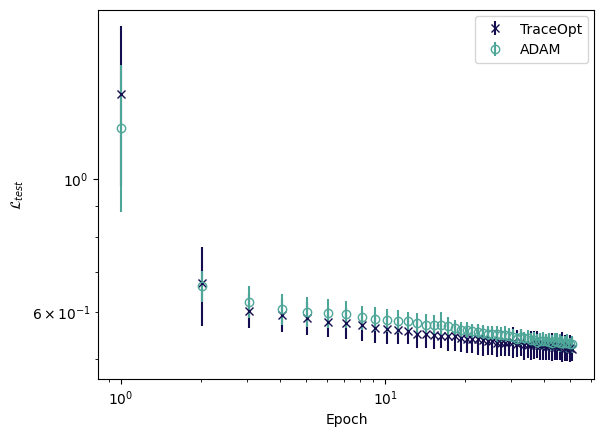

In [8]:
x = np.linspace(1, 51, 50)

plt.errorbar(
    x,
    np.mean(traceopt_data, axis=0), 
    yerr=np.std(traceopt_data, axis=0),
    marker='x', 
    c = "#140D4F",
    mfc="none",
    linestyle="none",
    label="TraceOpt"
)
plt.errorbar(
    x,
    np.mean(adam_data, axis=0), 
    yerr=np.std(adam_data, axis=0),
    marker='o', 
    mfc="none",
    c="#4EA699",
    linestyle="none",
    label="ADAM"
)

plt.xlabel("Epoch")
plt.ylabel(r"$\mathcal{L}_{test}$")
plt.yscale("log")
plt.xscale("log")
plt.legend()
# plt.savefig("abalone-vs-adam.pdf")
plt.show()